# Extragerea contururilor

## Scopul lucrarii
Intr-o imagine, variatiile de valoare ale pixelilor reprezinta schimbari ale proprietatilor fizice sau geometrice ale scenei sau ale obiectului observat. Aceste schimbari pot corespunde fizic la variatiile iluminarii, schimbarile de orientare sau de distanta fata de observator, schimbari de reflectanta ale suprafetelor, variatii de absorbtie a radiatiei. Intr-un
numar mare de cazuri, aceste variatii de intensitate sunt informatii importante pentru operatiile ce urmeaza segmentarii, informatii ce corespund frontierelor regiunilor determinate de obiectele scenei.

## Metoda de gradient
Principiul acestei metode consta in definirea punctelor de contur ca fiind acei pixeli ai imaginii in care apar schimbari importante (abrupte) ale nivelului de gri. Deci, masurarea acestei variatii se va face prin operatori derivativi de tip gradient. Pentru o imagine cu suport spatial continuu, pe directia unei muchii, derivata va fi maxima. Derivata imaginii pe directia $r$, ce face unghiul $\theta $ cu orizontala, este data de combinatia liniara a derivatelor partiale pe directiile orizontala si verticala:
\begin{equation}
\frac{\partial f}{\partial r}=\frac{\partial f}{\partial x}\frac{\partial x}{\partial r}+\frac{\partial f}{\partial y}\frac{\partial y}{\partial r}=\frac{\partial f}{\partial x}\cos \theta +\frac{\partial f}{\partial y}\sin \theta
\end{equation}

\begin{equation}
\frac{\partial f}{\partial r}=f_{x}\cos \theta +f_{y}\sin \theta
\end{equation}

Valoarea maxima a acestei derivate, calculate dupa unghiul $\theta$ este data de ecuatia
\begin{equation}
\frac{\partial}{\partial \theta }\left( \frac{\partial f}{\partial r} \right) =-f_{x}\sin \theta +f_{y}\cos \theta =0 \end{equation}

Ecuatia anterioara are solutia evidenta:
\begin{equation}
\theta _{0}=\arctan \left( \frac{f_{y}}{f_{x}}\right)
\end{equation}

Pe aceasta directie, modulul gradientului este:
\begin{equation}
\left( \frac{\partial f}{\partial r}\right) _{\max }=\sqrt{f_{x}^{2}+f_{y}^{2}}
\end{equation}

Din punct de vedere practic, implementarea acestei metode impune calcularea, pentru fiecare punct al imaginii, a derivatelor partiale $f_{x}$ si $f_{y}$, calcularea modulului gradientului maxim si a directiei acestuia. Valoarea gradientului maxim din fiecare punct al imaginii este apoi comparata cu un prag fixat: daca pragul este depasit (deci gradientul maxim in pixelul respectiv este suficient de important) atunci pixelul testat este pixel de contur.

Putem avea mai multe expresii simple, imediate, ale derivatelor pe orizontala si verticala:
\begin{equation}
f_{x}=f(m,n)-f(m+1,n),\,f_{y}=f(m,n)-f(m,n+1)
\end{equation}
\begin{equation}
f_{x}=f(m-1,n)-f(m,n),\,f_{y}=f(m,n-1)-f(m,n)
\end{equation}
\begin{equation}
f_{x}=f(m-1,n)-f(m+1,n),\,f_{y}=f(m,n-1)-f(m,n+1)
\end{equation}


## Ce vom coda
O schema simpla de calcul a gradientilor fundamentali, calculul intensitatii maxime de tranzitie si praguirea acesteia pentru a determina harta binara de contururi pentru o imagine scalara.

Evident ca derivarea este o operatie de filtrare liniara (convolve2d cu bordare si pastrarea dimensiunii imaginii obtinute)

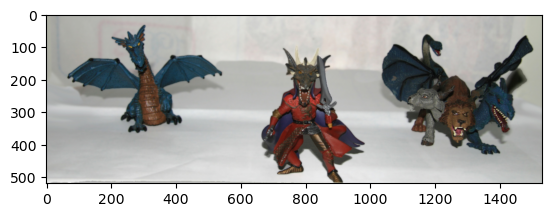

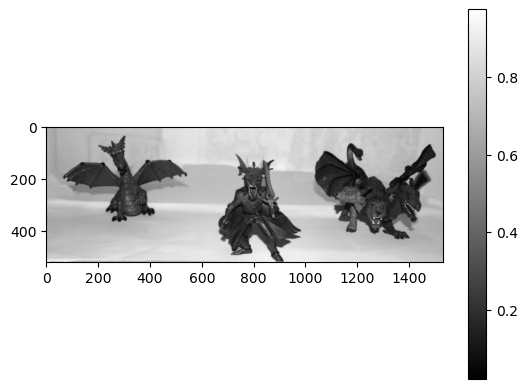

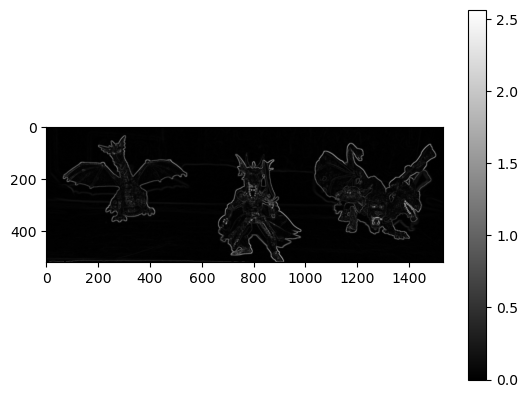

(<Figure size 640x480 with 2 Axes>,
 None)

In [30]:
import numpy as np
from skimage import io,color
import matplotlib.pyplot as plt
from scipy import signal

img=io.imread('poza1.jpg') # de incercat si cu lena
Y = color.rgb2gray(img)

# kernel orizontal

kernelH=np.zeros((3,3))
kernelH[1,0]=-1
kernelH[1,2]=1
kernelH[0,0]=-1
kernelH[0,2]=1
kernelH[2,0]=-1
kernelH[2,2]=1

# kernel vertical
kernelV=np.zeros((3,3))
kernelV[0,1]=-1
kernelV[2,1]=1
kernelV[0,0]=-1
kernelV[2,0]=1
kernelV[0,2]=-1
kernelV[2,2]=1

YH = signal.convolve2d(Y, kernelV, mode='same', boundary='symm')
YV = signal.convolve2d(Y, kernelH, mode='same', boundary='symm')
contur_map=np.abs(YH)+np.abs(YV)    # harta de intensitati

plt.figure(), plt.imshow(img), plt.show()
plt.figure(), plt.imshow(Y, cmap = 'gray'), plt.colorbar(), plt.show()
plt.figure(), plt.imshow(contur_map, cmap = 'gray'), plt.colorbar(), plt.show()


# pe gri
# si jos la aplicarea color e codul pt color


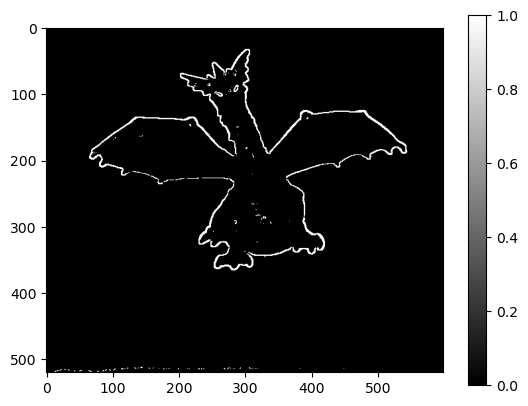

(<Figure size 640x480 with 2 Axes>,
 None)

In [32]:
plt.figure(), plt.imshow(contur_map[:, 0:599] >= 0.6, cmap = 'gray'), plt.colorbar(), plt.show()  # testat si pt 0.5 si 0.4 si din ce in ce mai jos pana se vad bine contururile
# 0.6 pt ca am 3 sume acum => echivalentul a 0.2 de dinainte de la cel cu matricea:
#  0  0  0
# -1  0  1
#  0  0  0


# si acum e
# -1 0 1
# -1 0 1
# -1 0 1


## Gradientul netezit
Folosirea mastilor de derivare pe verticala si orizontala prezentate are insa serioase neajunsuri: dimensiunea lor mica face ca rezultatele sa fie extrem de sensibile la zgomot. In aceste conditii a aparut naturala ideea de a combina filtrarea de derivare cu o filtrare de netezire, care sa mai reduca efectele zgomotului. Considerand zgomotul de tip gaussian, aditiv, filtrarea de netezire are ca efect secundar micsorarea contrastului frontierelor obiectelor din imagine (efectul de incetosare, sau blur). Pentru ca in aceste conditii detectia contururilor sa nu fie afectata, trebuie ca operatia de mediere prin care se realizeaza netezirea sa se faca pe o directie perpendiculara directiei contururilor cautate.
Atunci derivarea pe verticala se combina cu o operatie de netezire cu masca orizontala
$\left(
\begin{array}{lll}
1/3 & \frame{1/3} & 1/3
\end{array}
\right)$
si derivarea pe orizontala se combina cu o operatie de netezire cu masca verticala
$\left(
\begin{array}{l}
1/3 \\
\frame{1/3} \\
1/3
\end{array}
\right)$.

In cazul general se pot folosi Insa pentru netezire medieri ponderate (si nu neaparat medieri aritmetice), care sa acorde o mai mare importanta pixelului curent prelucrat, ca de exemplu
$\frac{1}{c+2}\left(
\begin{array}{lll}
1 & \frame{c} & 1
\end{array}
\right) $

si se prefera folosirea operatorilor de derivare simetrici. Ceea ce rezulta pentru operatorii de derivare orizontala si verticala sunt mastile:
$
W_{x}=\left(
\begin{array}{lll}
1 & 0 & -1 \\
c & \frame{0} & -c \\
1 & 0 & -1
\end{array}
\right) $
$W_{y}=\left(
\begin{array}{lll}
1 & c & 1 \\
0 & \frame{0} & 0 \\
-1 & -c & -1
\end{array}
\right)$

Prin particularizarea valorilor constantei de ponderare $c$ se pot obtine diferite tipuri de operatori de extragere de contur clasici: Prewitt ($c=1$), Izotrop ($c=\sqrt{2}$), Sobel ($c=2$). Se remarca faptul ca constanta de ponderare globala a mastii de filtare este neesentiala, Intrucat conditia de normare ce trebuie Indeplinita este cea pentru filtre de contrastare (derivare): suma coeficientilor mastii sa fie nula.

## Ce vom coda
O schema simpla de calcul a gradientilor neteziti, calculul intensitatii maxime de tranzitie si praguirea acesteia pentru a determina harta binara de contururi pentru o imagine scalara.

Evident ca derivarea este o operatie de filtrare liniara (convolve2d cu bordare si pastrarea dimensiunii imaginii obtinute)

## Aplicarea la imagini color

La o imagine color masurile de variatie locala (magnitudinea gradientului, de exemplu) se pot calcula independent pe fiecare plan de culoare si apoi se poate agrega intr-un singur scalar (de exemplu cu norma L2).

Implementati o extragere de contur bazata pe tehnica de gradient pentru imagini color folosind toate canalele de culoare.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


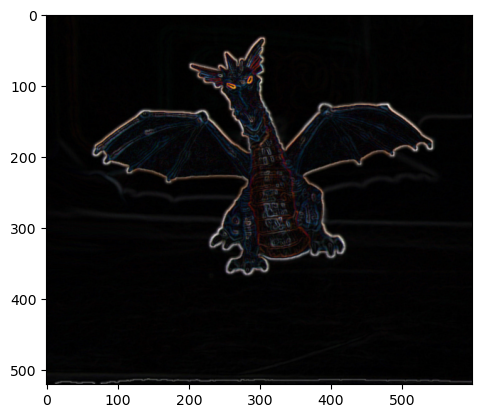

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


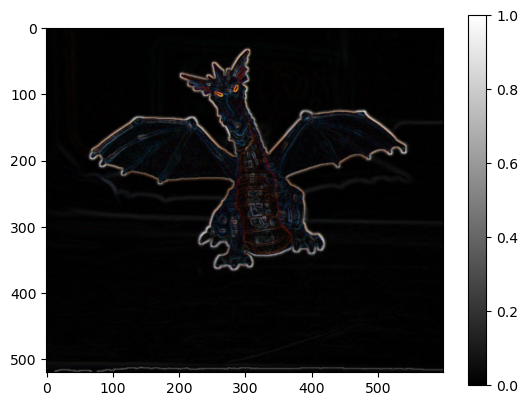

(<Figure size 640x480 with 2 Axes>,
 None)

In [24]:
img = img / 255.0

YH = np.zeros(np.shape(img))
YV = np.zeros(np.shape(img))

for p in range (0,3):
    YH[:,:,p] = signal.convolve2d(img[:,:,p], kernelV, mode='same', boundary='symm')
    YV[:,:,p] = signal.convolve2d(img[:,:,p], kernelH, mode='same', boundary='symm')
    
contur_map = (np.abs(YH) + np.abs(YV)) / 2
plt.figure(), plt.imshow(contur_map[:,0:599, :]), plt.show()

conturmap = np.sum(contur_map, axis = 2)

plt.figure(), plt.imshow(contur_map[:,0:599], cmap = 'gray'), plt.colorbar(), plt.show()

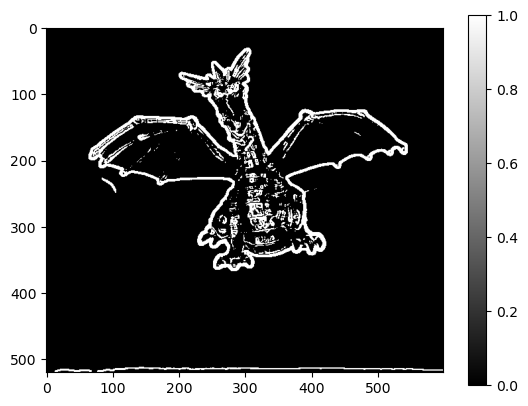

(<Figure size 640x480 with 2 Axes>,
 None)

In [29]:
plt.figure(), plt.imshow(contur_map[:, 0:599] >= 0.2, cmap = 'gray'), plt.colorbar(), plt.show() # inaninte sa rulez trebuie sa mai rulez inca o data prima caseta cu cod ca sa nu dea eroare